# Normalized SiPM counts vs distance from muon hit

This notebook reads `tengiz_output.csv`, where each `8 x 8` matrix is one muon-hit event and each entry is the photon count seen by one SiPM.

Assumptions used here:
- All matrices correspond to the same muon-hit position at `(x, z) = (10, 10)` cm.
- The SiPM layout is the same `8 x 8` grid on the `50 x 50 cm` slab.
- `normalized_count` is defined as `avg_count / max(avg_count)`, because there is no SiPM exactly at zero distance from the hit.
- For the requested overlay with `s = 0`, the model has `I(0) = \infty`, so the exact normalized curve `I(x)/I(0)` is `0` for every measured `x > 0`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

csv_path = Path("tengiz_output.csv")

slab_size_cm = 50.0
pitch_cm = 6.25
n_sipm_per_side = 8
muon_hit_cm = (0.0, 0.0)


In [2]:
def load_matrix_csv(path: Path) -> np.ndarray:
    matrices = []
    current_rows = []

    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()

        if not line:
            if current_rows:
                matrices.append(np.array(current_rows, dtype=float))
                current_rows = []
            continue

        if line.startswith("Matrix "):
            continue

        current_rows.append([float(value) for value in line.split(",")])

    if current_rows:
        matrices.append(np.array(current_rows, dtype=float))

    matrix_stack = np.stack(matrices)
    expected_shape = (n_sipm_per_side, n_sipm_per_side)

    if matrix_stack.shape[1:] != expected_shape:
        raise ValueError(f"Expected per-hit matrix shape {expected_shape}, got {matrix_stack.shape[1:]}")

    return matrix_stack


matrix_stack = load_matrix_csv(csv_path)
matrix_stack.shape


(1000, 8, 8)

In [3]:
half_size_cm = slab_size_cm / 2
axis_coords_cm = np.linspace(
    -half_size_cm + pitch_cm / 2,
    half_size_cm - pitch_cm / 2,
    n_sipm_per_side,
)

mean_counts = matrix_stack.mean(axis=0)
std_counts = matrix_stack.std(axis=0)
stderr_counts = std_counts / np.sqrt(matrix_stack.shape[0])

x_grid, z_grid = np.meshgrid(axis_coords_cm, axis_coords_cm)
distance_grid = np.sqrt((x_grid - muon_hit_cm[0]) ** 2 + (z_grid - muon_hit_cm[1]) ** 2)

sipm_summary = pd.DataFrame(
    {
        "row": np.repeat(np.arange(n_sipm_per_side), n_sipm_per_side),
        "col": np.tile(np.arange(n_sipm_per_side), n_sipm_per_side),
        "x_cm": x_grid.ravel(),
        "z_cm": z_grid.ravel(),
        "distance_cm": distance_grid.ravel(),
        "avg_count": mean_counts.ravel(),
        "stderr_count": stderr_counts.ravel(),
    }
)

max_avg_count = sipm_summary["avg_count"].max()
sipm_summary["normalized_count"] = sipm_summary["avg_count"] / max_avg_count
sipm_summary["normalized_stderr"] = sipm_summary["stderr_count"] / max_avg_count

sipm_summary = sipm_summary.sort_values(["distance_cm", "row", "col"]).reset_index(drop=True)

sipm_summary["model_I_over_I0_s0"] = 0.0
ss_res = np.sum((sipm_summary["normalized_count"] - sipm_summary["model_I_over_I0_s0"]) ** 2)
ss_tot = np.sum((sipm_summary["normalized_count"] - sipm_summary["normalized_count"].mean()) ** 2)
model_r_squared = 1 - ss_res / ss_tot
sipm_summary.head(12)


,row,col,x_cm,z_cm,distance_cm,avg_count,stderr_count,normalized_count,normalized_stderr,model_I_over_I0_s0
0,3,3,-3.125,-3.125,4.419417,446.910,2.732393,0.997885,0.006101,0.0
1,3,4,3.125,-3.125,4.419417,447.482,2.749259,0.999163,0.006139,0.0
2,4,3,-3.125,3.125,4.419417,447.857,2.737175,1.000000,0.006112,0.0
3,4,4,3.125,3.125,4.419417,446.987,2.757900,0.998057,0.006158,0.0
4,2,3,-3.125,-9.375,9.882118,236.223,1.471682,0.527452,0.003286,0.0
5,2,4,3.125,-9.375,9.882118,234.663,1.499774,0.523969,0.003349,0.0
6,3,2,-9.375,-3.125,9.882118,235.709,1.491169,0.526304,0.003330,0.0
7,3,5,9.375,-3.125,9.882118,235.357,1.497551,0.525518,0.003344,0.0
8,4,2,-9.375,3.125,9.882118,235.768,1.474851,0.526436,0.003293,0.0
9,4,5,9.375,3.125,9.882118,235.750,1.507544,0.526396,0.003366,0.0


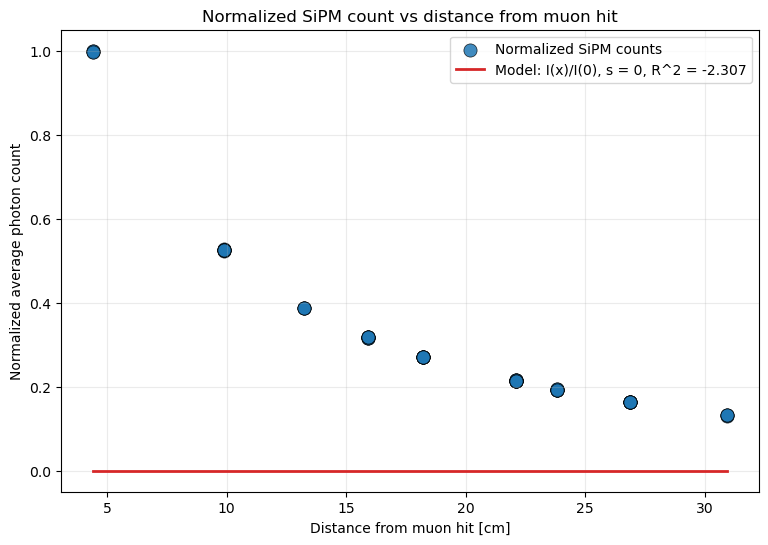

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    sipm_summary["distance_cm"],
    sipm_summary["normalized_count"],
    s=90,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
    label="Normalized SiPM counts",
)

ax.plot(
    sipm_summary["distance_cm"],
    sipm_summary["model_I_over_I0_s0"],
    color="tab:red",
    linewidth=2,
    label=f"Model: I(x)/I(0), s = 0, R^2 = {model_r_squared:.3f}",
)

ax.set_title("Normalized SiPM count vs distance from muon hit")
ax.set_xlabel("Distance from muon hit [cm]")
ax.set_ylabel("Normalized average photon count")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


In [5]:
normalized_table = sipm_summary[["distance_cm", "normalized_count"]].copy()
normalized_table["distance_cm"] = normalized_table["distance_cm"].round(6)
normalized_table["normalized_count"] = normalized_table["normalized_count"].round(6)
normalized_table


,distance_cm,normalized_count
0,4.419417,0.997885
1,4.419417,0.999163
2,4.419417,1.000000
3,4.419417,0.998057
4,9.882118,0.527452
...,...,...
59,26.882266,0.164595
60,30.935922,0.130727
61,30.935922,0.131609
62,30.935922,0.131955


In [6]:
pd.set_option('display.max_rows', None)



In [7]:
normalized_table

,distance_cm,normalized_count
0,4.419417,0.997885
1,4.419417,0.999163
2,4.419417,1.000000
3,4.419417,0.998057
4,9.882118,0.527452
5,9.882118,0.523969
6,9.882118,0.526304
7,9.882118,0.525518
8,9.882118,0.526436
9,9.882118,0.526396


In [9]:
print([i for i in normalized_table['distance_cm']])

[4.419417, 4.419417, 4.419417, 4.419417, 9.882118, 9.882118, 9.882118, 9.882118, 9.882118, 9.882118, 9.882118, 9.882118, 13.258252, 13.258252, 13.258252, 13.258252, 15.934436, 15.934436, 15.934436, 15.934436, 15.934436, 15.934436, 15.934436, 15.934436, 18.221725, 18.221725, 18.221725, 18.221725, 18.221725, 18.221725, 18.221725, 18.221725, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 22.097087, 23.799291, 23.799291, 23.799291, 23.799291, 23.799291, 23.799291, 23.799291, 23.799291, 26.882266, 26.882266, 26.882266, 26.882266, 26.882266, 26.882266, 26.882266, 26.882266, 30.935922, 30.935922, 30.935922, 30.935922]
